# Business Objective

Perusahaan bergerak di bidang layanan keuangan digital dan sedang berusaha meningkatkan retensi pengguna serta pendapatan jangka panjang. Namun, manajemen merasa bahwa pemasaran yang dilakukan saat ini belum menargetkan segmen pelanggan yang tepat.

# Identifikasi Masalah

Mendefinisikan pernyataan masalah menggunakan **Kerangka Kerja SMART**:


1. Specific (S): Meningkatkan nilai rata-rata Customer Lifetime Valuepengguna aplikasi.

2. Measurable (M): Target kenaikan sebesar 10% dari rata-rata LTV saat ini

3. Achievable (A): Target dapat dicapai melalui strategi berbasis insight data yang mempengaruhi LTV

4. Relevant (R): Membantu perusahaan fintech meningkatkan profitabilitas jangka panjang melalui retensi pengguna.

5. Time-Bound (T): Target ini dicapai dalam waktu 5 bulan.

**Pernyataan Masalah**:
Meningkatkan Customer Lifetime Value (LTV) rata-rata pengguna sebesar 10% melalui strategi promosi berbasis metode pembayaran dalam kurun waktu 5 bulan ke depan.

# Breaking Down the Problem

**Main Problem**:
Untuk memudahkan dalam analisis dan memecahkan masalah, perlu memahami detail dari permasalahan. Metode yang digunakan yakni 5W+1H:

Untuk memudahkan dalam analisis dan memecahkan masalah, perlu memahami detail dari permasalahan. Metode yang digunakan yakni 5W+1H:
1. Wilayah yang menyumbang total pendapatan terbesar?
2. Apakah tingkat pendapatan mempengaruhi total pengeluaran?
3. Bagaimana rata-rata transaksi berdasarkan umur pengguna?
4. Metode pembayaran apa yang paling sering digunakan oleh pengguna?
5. Apakah pengguna yang sering menghubungi Customer Service memiliki total pengeluaran yang lebih rendah?
6. Apakah pengguna yang menerima cashback lebih tinggi cenderung memiliki frekuensi penggunaan aplikasi yang lebih sering?

# Data Loading

Sumber dataset: FinTech Customer Life Time Value (LTV) Dataset

Link dataset kaggle : [LINK](https://www.kaggle.com/datasets/harunrai/fintech-customer-life-time-value-ltv-dataset)

In [2]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistik
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew, kurtosis
from scipy.stats import shapiro
from scipy import stats

# Visual lebih rapi
sns.set(style='whitegrid')

In [3]:
df = pd.read_csv('F:\Belajar\Belajar_GIt\Week 1\p1-coda015-rmt-m2-christoperly\digital_wallet_ltv_datasetss.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Yosseri\AppData\Local\Temp\ipykernel_15676\2960550460.py:1: SyntaxWarning: invalid escape sequence '\B'
  df = pd.read_csv('F:\Belajar\Belajar_GIt\Week 1\p1-coda015-rmt-m2-christoperly\digital_wallet_ltv_datasetss.csv')


,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.38402,60216.83451,6525.814861,3213385,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,327954
1,cust_0001,67,Suburban,High,979,14536.73468,48350.10027,2186.742245,14231463,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1437052
2,cust_0002,44,Urban,High,329,7061.37280,32521.15719,2743.406808,2323191,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,241938
3,cust_0003,30,Rural,High,71,16426.87645,17827.89672,4360.784994,1166308,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,128459
4,cust_0004,58,Urban,Middle,878,10800.09266,17497.63453,4532.872520,9482481,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,956951


In [4]:
df.columns

Index(['Customer_ID', 'Age', 'Location', 'Income_Level', 'Total_Transactions',
       'Avg_Transaction_Value', 'Max_Transaction_Value',
       'Min_Transaction_Value', 'Total_Spent', 'Active_Days',
       'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned', 'Referral_Count',
       'Cashback_Received', 'App_Usage_Frequency', 'Preferred_Payment_Method',
       'Support_Tickets_Raised', 'Issue_Resolution_Time',
       'Customer_Satisfaction_Score', 'LTV'],
      dtype='str')

In [5]:
# Menampilkan jumlah kolom dan baris.
print(f'Jumlah Kolom:{df.shape[1]}\nJumlah Baris:{df.shape[1]}')

Jumlah Kolom:20
Jumlah Baris:20


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  7000 non-null   str    
 1   Age                          7000 non-null   int64  
 2   Location                     7000 non-null   str    
 3   Income_Level                 7000 non-null   str    
 4   Total_Transactions           7000 non-null   int64  
 5   Avg_Transaction_Value        7000 non-null   float64
 6   Max_Transaction_Value        7000 non-null   float64
 7   Min_Transaction_Value        7000 non-null   float64
 8   Total_Spent                  7000 non-null   int64  
 9   Active_Days                  7000 non-null   int64  
 10  Last_Transaction_Days_Ago    7000 non-null   int64  
 11  Loyalty_Points_Earned        7000 non-null   int64  
 12  Referral_Count               7000 non-null   int64  
 13  Cashback_Received            

In [7]:
df['Total_Spent'] = df['Total_Spent'].astype(int)
df['LTV'] = df['LTV'].astype(int)

In [8]:
# hanya pakai 2 desimal terakhir
df = df.round(2)

In [9]:
df.describe()

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,42.633714,501.221429,9946.831437,30159.596781,2981.549969,5.002021e+06,181.934857,183.847714,2501.545429,24.837000,2496.525033,10.017571,36.528003,5.479000,5.119192e+05
std,15.516036,286.277311,5780.880820,21996.108766,2197.342208,4.390495e+06,105.102598,105.063709,1446.680026,14.560352,1440.651371,6.037067,20.389427,2.860197,4.390551e+05
min,16.000000,1.000000,10.190000,31.860000,4.620000,1.498000e+03,1.000000,1.000000,0.000000,0.000000,0.230000,0.000000,1.020000,1.000000,3.770000e+03
25%,29.000000,252.000000,4907.465000,12224.330000,1233.065000,1.363990e+06,90.000000,93.000000,1254.750000,12.000000,1269.425000,5.000000,19.130000,3.000000,1.482058e+05
50%,43.000000,506.000000,9841.170000,25469.390000,2473.185000,3.756104e+06,182.000000,184.000000,2466.000000,25.000000,2478.945000,10.000000,36.260000,5.000000,3.878175e+05
75%,56.000000,744.000000,14955.050000,44515.415000,4378.757500,7.645507e+06,273.000000,275.000000,3792.250000,37.000000,3749.375000,15.000000,54.070000,8.000000,7.748572e+05
max,69.000000,1000.000000,19996.450000,98809.240000,9917.030000,1.946773e+07,365.000000,365.000000,5000.000000,50.000000,4999.700000,20.000000,71.980000,10.000000,1.956987e+06


# Data Cleaning

In [10]:
# Menghitung persentase terhadap missing value tiap kolom
percent_missing = df.isnull().sum() * 100 / len(df)
missing_values_df = pd.DataFrame({'column_name': df.columns,
                                  'percent_missing': percent_missing})
missing_values_df

,column_name,percent_missing
Customer_ID,Customer_ID,0.0
Age,Age,0.0
Location,Location,0.0
Income_Level,Income_Level,0.0
Total_Transactions,Total_Transactions,0.0
Avg_Transaction_Value,Avg_Transaction_Value,0.0
Max_Transaction_Value,Max_Transaction_Value,0.0
Min_Transaction_Value,Min_Transaction_Value,0.0
Total_Spent,Total_Spent,0.0
Active_Days,Active_Days,0.0


Berdasarkan data di atas bisa dipastikan tidak ada data yang kosong dan semua terisi.


In [11]:
# Cek data duplikat
df.duplicated().sum()

np.int64(0)

Berdasarkan hasil pemeriksaan data, tidak ditemukan nilai duplikat maupun missing values pada dataset. Seluruh variabel memiliki tipe data yang sesuai dengan kebutuhan analisis.

Dengan demikian, dataset berada pada dalam kondisi yang bersih dan siap untuk dilanjutkan ke tahap eksplorasi data.

# Analisis dan Perhitungan

## Q1. Wilayah yang menyumbang total pendapatan terbesar?

          Customer_Count  Total_Revenue  Persentase
Location                                           
Suburban            2320    11801347823       33.70
Urban               2368    11741580802       33.53
Rural               2312    11471221015       32.76


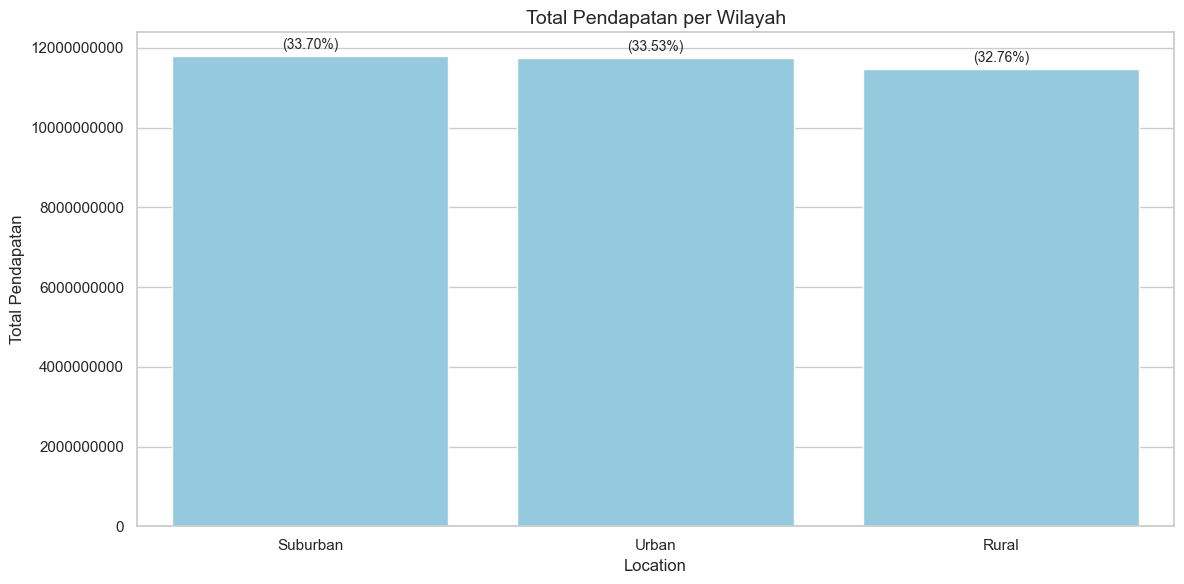

In [12]:
# lokasi
location_summary = df.groupby('Location').agg(
    Customer_Count=('Customer_ID', 'count'),
    Total_Revenue=('Total_Spent', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

# Hitung total revenue keseluruhan
total_revenue_all = location_summary['Total_Revenue'].sum()

# Hitung persentase kontribusi tiap wilayah
location_summary['Persentase'] = (location_summary['Total_Revenue'] / total_revenue_all) * 100

# Format angka supaya tidak scientific (1e10)
pd.options.display.float_format = '{:,.2f}'.format

# Tampilkan tabel
print(location_summary)

# Visualisasi

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=location_summary.index,
    y=location_summary['Total_Revenue'],
    color='skyblue'
)

plt.title('Total Pendapatan per Wilayah', fontsize=14)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Total Pendapatan')
plt.ticklabel_format(style='plain', axis='y')

# Label bar: revenue + persentase
labels = [f'({p:.2f}%)' for p in location_summary['Persentase']]
ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

### WARNA

Ringkasan Data per Lokasi:
          Customer_Count  Total_Revenue  Persentase
Location                                           
Suburban            2320    11801347823       33.70
Urban               2368    11741580802       33.53
Rural               2312    11471221015       32.76


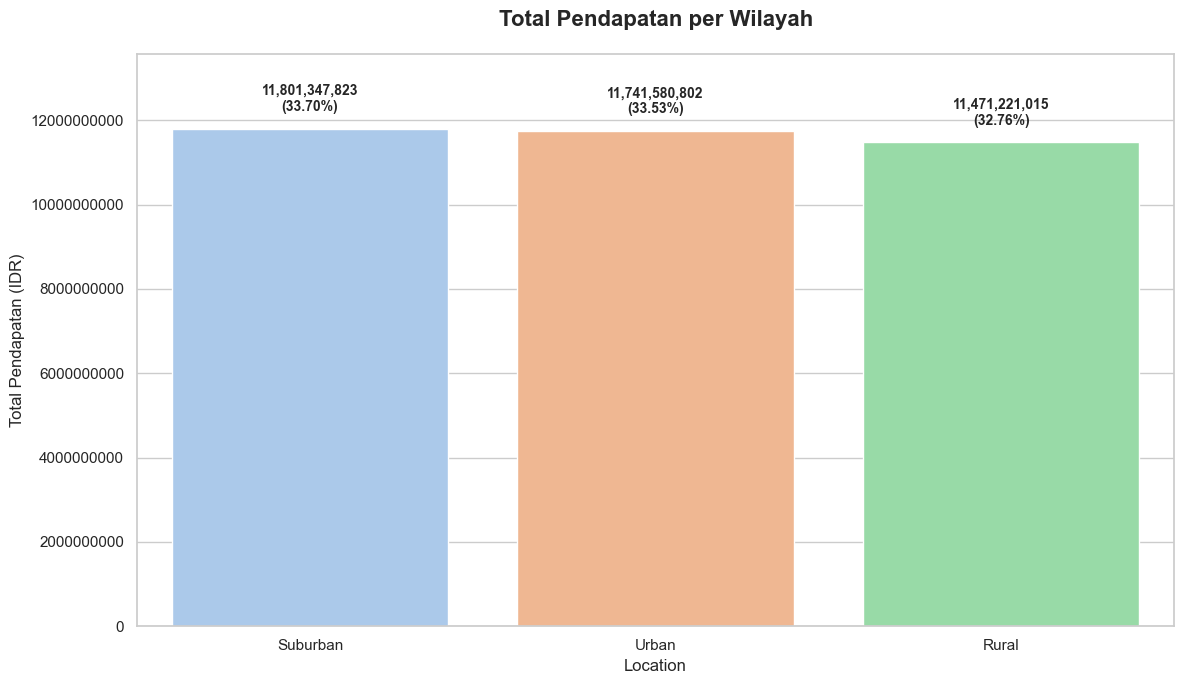

In [13]:
# --- 1. Persiapan Data (Lokasi) ---
# Mengelompokkan data berdasarkan Lokasi
location_summary = df.groupby('Location').agg(
    Customer_Count=('Customer_ID', 'count'),
    Total_Revenue=('Total_Spent', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

# Hitung total revenue keseluruhan untuk persentase
total_revenue_all = location_summary['Total_Revenue'].sum()

# Hitung persentase kontribusi tiap wilayah
location_summary['Persentase'] = (location_summary['Total_Revenue'] / total_revenue_all) * 100

# Format angka tabel agar tidak scientific (1e10)
pd.options.display.float_format = '{:,.2f}'.format

# Tampilkan tabel di console
print("Ringkasan Data per Lokasi:")
print(location_summary)


# --- 2. Visualisasi ---
plt.figure(figsize=(12, 7))

# Menggunakan palette 'pastel' agar warna tiap batang berbeda (seperti di foto)
# hue=location_summary.index digunakan agar tidak muncul FutureWarning
ax = sns.barplot(
    x=location_summary.index, 
    y=location_summary['Total_Revenue'], 
    palette='pastel', 
    hue=location_summary.index,
    legend=False
)

# Pengaturan Judul dan Label
plt.title('Total Pendapatan per Wilayah', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Total Pendapatan (IDR)', fontsize=12)

# Menghilangkan format scientific (seperti 1e6) pada sumbu Y
plt.ticklabel_format(style='plain', axis='y')

# --- 3. Menambahkan Label (Nilai + Persentase) di atas Bar ---
# Loop ini akan menaruh teks tepat di atas setiap batang
for i, p in enumerate(ax.patches):
    # Ambil nilai revenue dan persentase
    revenue_val = location_summary['Total_Revenue'].iloc[i]
    percent_val = location_summary['Persentase'].iloc[i]
    
    # Format teks: Angka Ribuan + Persentase di bawahnya
    label_text = f'{revenue_val:,.0f}\n({percent_val:.2f}%)'
    
    # Letakkan teks
    ax.text(
        p.get_x() + p.get_width() / 2.,     # Posisi X: tengah batang
        p.get_height() + (total_revenue_all * 0.01), # Posisi Y: sedikit di atas batang
        label_text, 
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Memberikan ruang agar label tidak terpotong di bagian atas
plt.ylim(0, location_summary['Total_Revenue'].max() * 1.15)

plt.tight_layout()
plt.show()

## Q2. Apakah tingkat pendapatan mempengaruhi total pengeluaran?

Pendekatan yang dilakukan adalah ANOVA

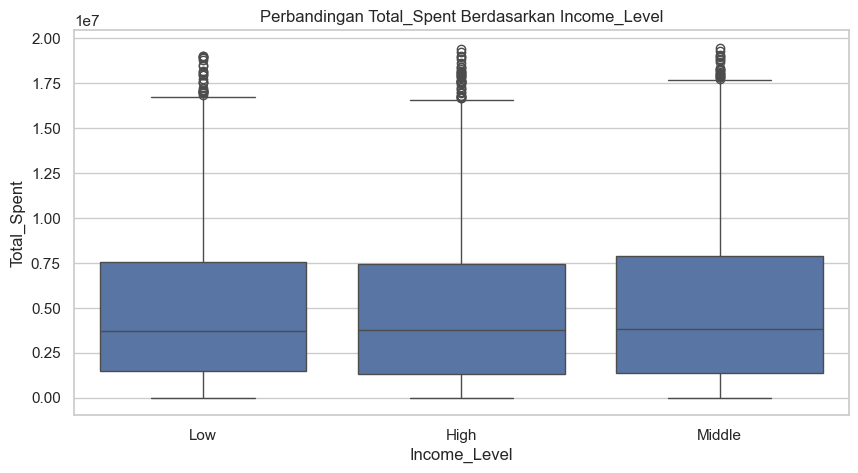

In [14]:
# Visualisasi
plt.figure(figsize=(10,5))
plt.title('Perbandingan Total_Spent Berdasarkan Income_Level')
sns.boxplot(x='Income_Level', y='Total_Spent', data=df)

# Menampilkan hasil
plt.show()

Berdasarkan boxplot, distribusi Total_Spent pada ketiga kategori Income_Level (Low, Middle, High) terlihat relatif mirip. Median masing-masing kelompok tidak menunjukkan perbedaan yang mencolok, serta terdapat banyak outlier pada setiap kategori.

Hal ini mengindikasikan bahwa pola pengeluaran pelanggan cenderung tidak jauh berbeda meskipun tingkat pendapatan berbeda.

## Statistik Inferensial

H0: Tidak perbedaan yang signifikan antara Total_Spent dan Income_Level

H1: Ada perbedaan signifikan

In [15]:
# Mengelompokkan data
low = df[df['Income_Level'] == 'Low']['Total_Spent']
middle = df[df['Income_Level'] == 'Middle']['Total_Spent']
high = df[df['Income_Level'] == 'High']['Total_Spent']

# One-Way  Anova
f_stat, p_val = stats.f_oneway(low,middle,high)

print(f'F-statistic: {f_stat:.4f}')
print(f'P-Value: {p_val:.4f}')

# Interpretasi hasil
if p_val < 0.05:
    print("Ada perbedaan signifikan dalam pengeluaran antar tingkat pendapatan.")
else:
    print("Tidak ada perbedaan signifikan dalam pengeluaran antar tingkat pendapatan.")


F-statistic: 1.2937
P-Value: 0.2743
Tidak ada perbedaan signifikan dalam pengeluaran antar tingkat pendapatan.


## Q3. Bagaimana rata-rata transaksi berdasarkan umur pengguna?

                         mean  count
Age_Group                           
Remaja (<25)         9,991.88   1247
Dewasa Muda (25-45)  9,896.08   2639
Dewasa (45-65)      10,009.51   2596
Senior (>65)         9,782.78    518


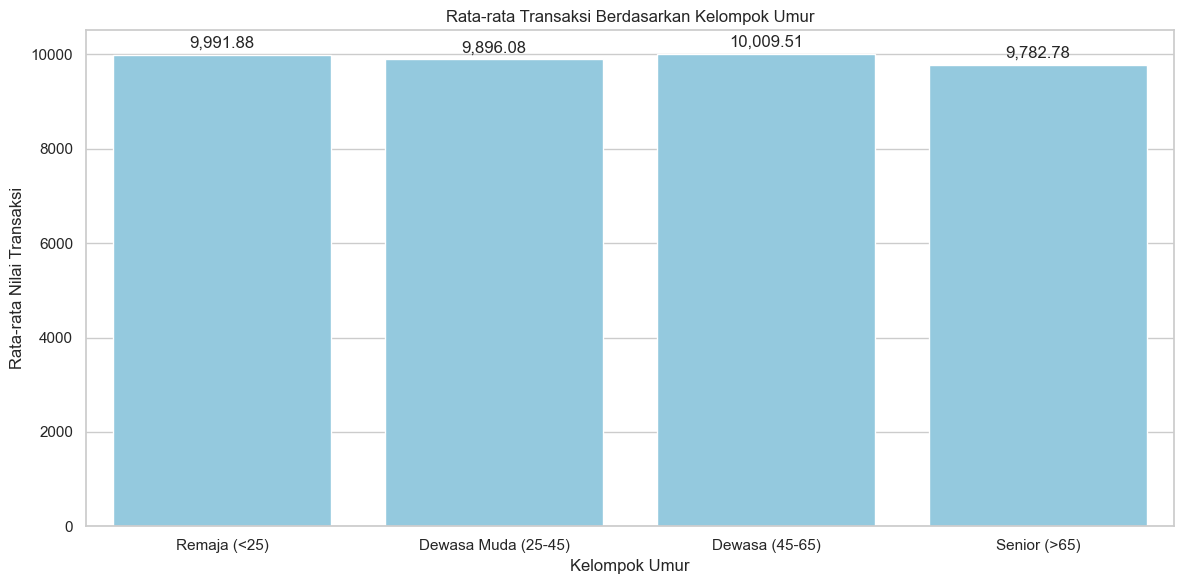

In [16]:
# Membuat kategori umur
bins = [0, 25, 45, 65, 100]
labels = ['Remaja (<25)', 'Dewasa Muda (25-45)', 'Dewasa (45-65)', 'Senior (>65)']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Ringkasan data
age_summary = df.groupby('Age_Group')['Avg_Transaction_Value'].agg(['mean','count'])
print(age_summary)

# Menghitung rata-rata per kelompok
avg_data = df.groupby('Age_Group')['Avg_Transaction_Value'].mean().reset_index()

# Visualisasi
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x='Age_Group',
    y='Avg_Transaction_Value',
    data=avg_data,
    color='skyblue'
)

plt.title('Rata-rata Transaksi Berdasarkan Kelompok Umur')
plt.xlabel('Kelompok Umur')
plt.ylabel('Rata-rata Nilai Transaksi')

# Label nilai di atas bar
labels = [f'{v:,.2f}' for v in avg_data['Avg_Transaction_Value']]
ax.bar_label(ax.containers[0], labels=labels, padding=3)

plt.tight_layout()
plt.show()

Nilai transaksi rata-rata antar kelompok umur cenderung stabil dan tidak menunjukkan perbedaan yang mencolok. Hal ini mengindikasikan bahwa daya beli pengguna relatif merata di semua retang usia. Bisa disimpulkan bahwa usia bukan faktor utama.

## Q4. Metode pembayaran apa yang paling sering digunakan oleh pengguna?

  Preferred_Payment_Method  Count  Percentage
0                      UPI   1791       25.59
1               Debit Card   1761       25.16
2           Wallet Balance   1736       24.80
3              Credit Card   1712       24.46


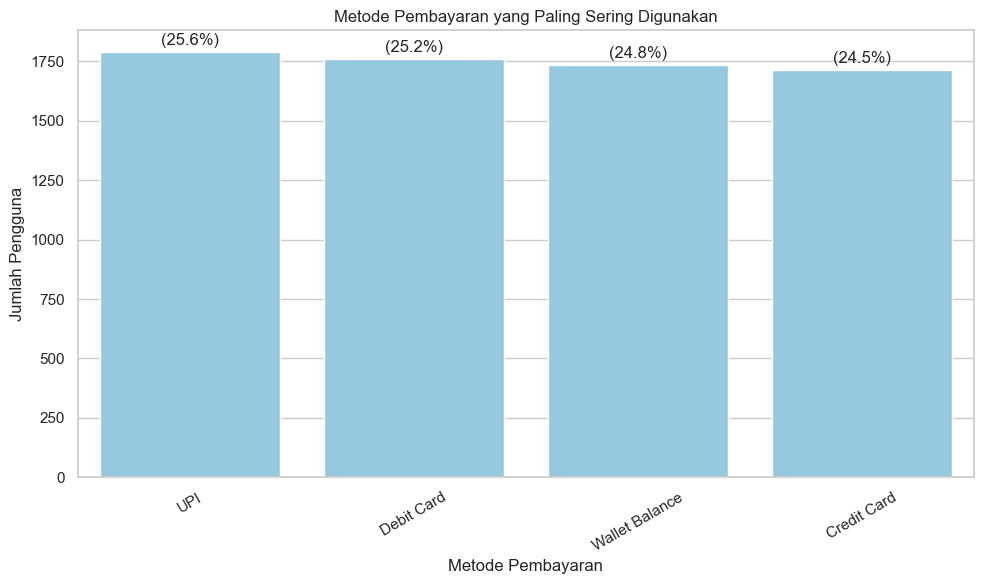

In [17]:
# Menghitung frekuensi metode pembayaran
payment_counts = df['Preferred_Payment_Method'].value_counts().reset_index()
payment_counts.columns = ['Preferred_Payment_Method', 'Count']

# Menghitung persentase
total_users = payment_counts['Count'].sum()
payment_counts['Percentage'] = (payment_counts['Count'] / total_users) * 100

print(payment_counts)

# Visualisasi
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_counts,
    x='Preferred_Payment_Method',
    y='Count',
    color='skyblue'
)

plt.title('Metode Pembayaran yang Paling Sering Digunakan')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Pengguna')

# Label persentase
labels = [f'({p:.1f}%)' for p in payment_counts['Percentage']]
ax.bar_label(ax.containers[0], labels=labels, padding=3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### WARNA

Data Metode Pembayaran:
  Preferred_Payment_Method  Count  Percentage
0                      UPI   1791       25.59
1               Debit Card   1761       25.16
2           Wallet Balance   1736       24.80
3              Credit Card   1712       24.46


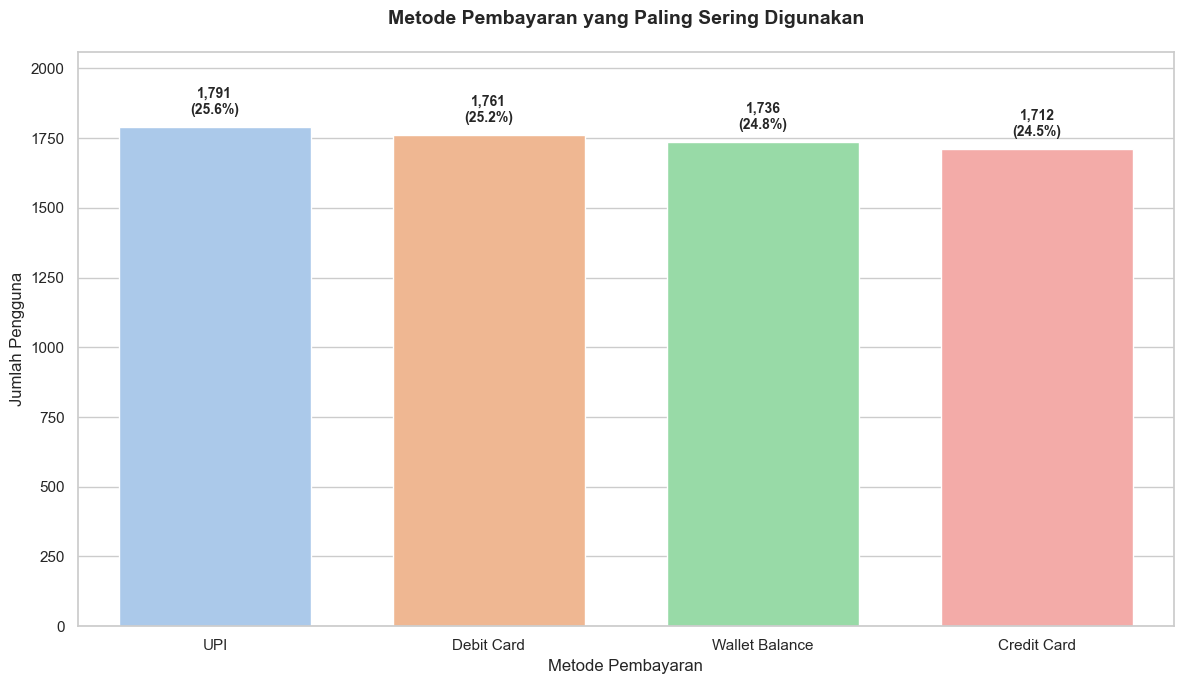

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Persiapan Data (Metode Pembayaran) ---
# Menghitung frekuensi metode pembayaran
payment_counts = df['Preferred_Payment_Method'].value_counts().reset_index()
payment_counts.columns = ['Preferred_Payment_Method', 'Count']

# Menghitung persentase
total_users = payment_counts['Count'].sum()
payment_counts['Percentage'] = (payment_counts['Count'] / total_users) * 100

# Menampilkan tabel di console
print("Data Metode Pembayaran:")
print(payment_counts)

# --- 2. Visualisasi ---
plt.figure(figsize=(12, 7))

# Menggunakan palette 'pastel' dan width=0.7 agar batang lebih proporsional
ax = sns.barplot(
    data=payment_counts,
    x='Preferred_Payment_Method',
    y='Count',
    palette='pastel',
    hue='Preferred_Payment_Method',
    legend=False,
    width=0.7
)

plt.title('Metode Pembayaran yang Paling Sering Digunakan', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Metode Pembayaran', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)

# Mencegah format scientific pada sumbu Y
plt.ticklabel_format(style='plain', axis='y')

# --- 3. Menambahkan Label (Jumlah + Persentase) di Tengah Batang ---
for i, p in enumerate(ax.patches):
    # Ambil nilai count dan persentase dari dataframe
    count_val = payment_counts['Count'].iloc[i]
    percent_val = payment_counts['Percentage'].iloc[i]
    
    # Format teks: Jumlah di baris atas, Persentase di baris bawah
    label_text = f'{count_val:,}\n({percent_val:.1f}%)'
    
    # Letakkan teks tepat di tengah (center) secara horizontal
    ax.text(
        p.get_x() + p.get_width() / 2., 
        p.get_height() + (payment_counts['Count'].max() * 0.02), 
        label_text, 
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Memberikan ruang di bagian atas agar label tidak terpotong
plt.ylim(0, payment_counts['Count'].max() * 1.15)

# Rotasi label sumbu X agar tidak bertabrakan
plt.xticks(rotation=0) # Ubah ke 30 jika teks sangat panjang
plt.tight_layout()
plt.show()

## Q5. Apakah pengguna yang sering menghubungi customer server memiliki total pengeluaran yang lebih rendah?

Korelasi Pearson: -0.0297
P-Value: 0.0131


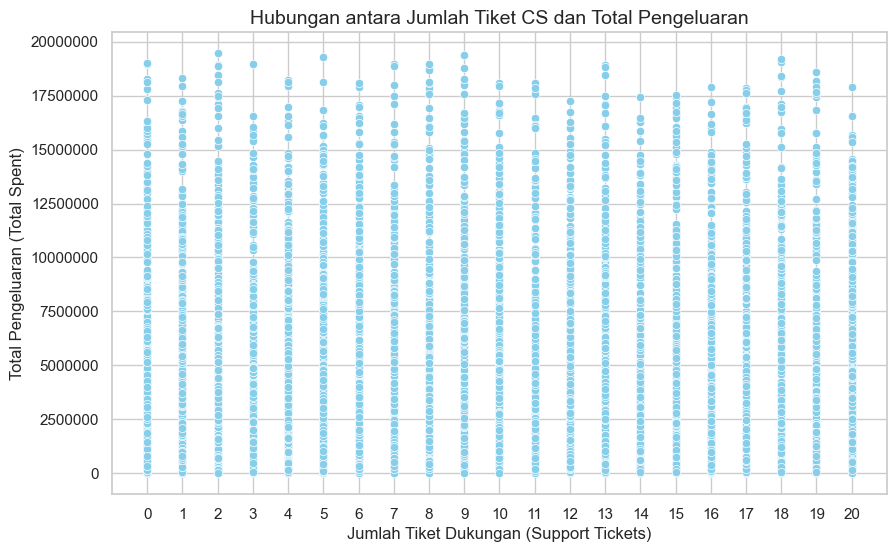

In [19]:
# Menghitung korelasi antara tiket CS dan Total Spent
correlation, p_value = stats.pearsonr(df['Support_Tickets_Raised'], df['Total_Spent'])

print(f"Korelasi Pearson: {correlation:.4f}")
print(f"P-Value: {p_value:.4f}")

# Visualisasi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
                x='Support_Tickets_Raised',
                y='Total_Spent',
                color='skyblue')

plt.title('Hubungan antara Jumlah Tiket CS dan Total Pengeluaran', fontsize=14)
plt.xlabel('Jumlah Tiket Dukungan (Support Tickets)', fontsize=12)
plt.ylabel('Total Pengeluaran (Total Spent)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Mematikan scientific notation
plt.xticks(sorted(df['Support_Tickets_Raised'].unique())) # untuk tau jumlah timket

plt.show()



Hasil uji Pearson korelasi sebesar -0.0297 dengan p-value 0.0131, menunjukkan bahwa kekuatan hubungan antara customer service dan total pengeluaran sangat lemah. 

Hal ini juga didukung oleh Scatter plot yang membuat pola penyebaran data secara acak dan merata di seluruh area plot. Hal ini menunjukkan bahwa pengguna yang lebih sering menghubungi customer service cenderung memiliki total pengeluaran yang lebih rendah.



## Q6. Bagaimana distribusi Customer Lifetime Value (LTV) pelanggan?

## Statistik Deskriptif

Statistik Deskriptif Customer Lifetime Value (LTV)
Mean LTV      : 511,919.21
Median LTV    : 387,817.50
Std Dev LTV   : 439,055.08
Minimum LTV   : 3,770.00
Maximum LTV   : 1,956,987.00


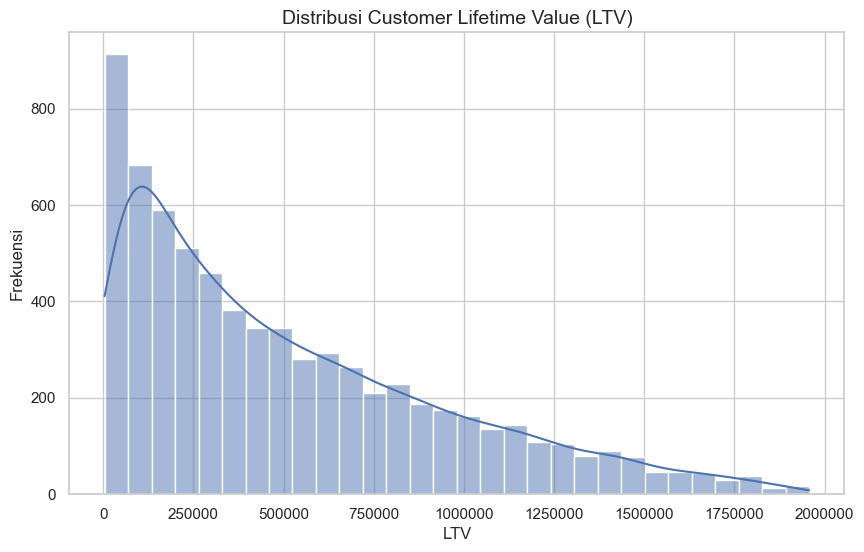

In [20]:
# Statistik deskriptif
mean_ltv = df['LTV'].mean()
median_ltv = df['LTV'].median()
std_ltv = df['LTV'].std()
min_ltv = df['LTV'].min()
max_ltv = df['LTV'].max()

print("Statistik Deskriptif Customer Lifetime Value (LTV)")
print(f"Mean LTV      : {mean_ltv:,.2f}")
print(f"Median LTV    : {median_ltv:,.2f}")
print(f"Std Dev LTV   : {std_ltv:,.2f}")
print(f"Minimum LTV   : {min_ltv:,.2f}")
print(f"Maximum LTV   : {max_ltv:,.2f}")

# Visualisasi
plt.figure(figsize=(10,6))

sns.histplot(df['LTV'], bins=30, kde=True)

plt.title("Distribusi Customer Lifetime Value (LTV)", fontsize=14)
plt.xlabel("LTV")
plt.ylabel("Frekuensi")
plt.ticklabel_format(style='plain', axis='x')  # Menghindari scientific notation

# Menampilkan Visual
plt.show()

Sebagian besar pelanggan meimiliki nilai LTV rendah hingga menengah, sementara hanya sedikit yang memiliki LTV yang sangat tinggi. Distribusi LTV cenderung miring ke kanan, jumlah sedikit tetapi kontribusinya besar.

# Kesimpulan

dari 6 pertanyaan tersebut, berikut kesimpulan yang dapat diperoleh:

1. Wilayah Pendapatan Terbesar berada di Wilayah Suburban menyumbang pendapatan tertinggi (33,70%), namun selisihnya sangat tipis dengan Urban dan Rural. Artinya, pasar anda sudah tersebar sangat merata di semua wilayah.

2. Pengaruh pendapatan terhadap pengeluaran berdasarkan uji ANOVA, tingkat pendapatan tidak mempengaruhi total pengeluaran secara signifikan (p-value > 0,05). Pelanggan berpenghasilan rendah maupun tinggi memiliki pola belanja yang serupa

3. Nilai transaksi di semua kelompok umur relatif stabil dan sama. Hal ini menunjukkan bahwa produk anda memiliki daya tarik yang sama bagi semua generasi, dari remaja hingga senior

4. Metode pembayaran yang sering digunakan adalah UPI, namun metode lain seperti Debit Card, dan Wallet juga tetap diminati. Pengguna cenderung menyukai fleksibilitas dalam memilih cara membayar

5. Pelanggan yang sering menghubungi customer service tidak terbunkti menurunkan pengeluaran mereka secara drastis. Keluhan pelanggan bukan merupakan indikator utama berkurangnya niat belanja.

6. Mayoritas pelanggan memiliki nilai ekonomi yang rendah hingga menengah. Pendapatan besar perusahaan hanya bergantung pada segelintir pelanggan eksklusif yang berbelanja sangat tinggi.

Menurut saya untuk Meningkatkan Customer Lifetime Value (LTV) rata-rata pengguna sebesar 10%
- Gunakan data Metode Pembayaran (Q4) untuk menentukan jenis promo. Karena UPI adalah metode yang paling populer (1.791 penggunaan), ini adalah saluran terbaik untuk menyebarkan promo.

Strategi: Berikan cashback atau potongan harga khusus jika pengguna bertransaksi menggunakan UPI.

- Bulan 1-2: Promo "Double Point" untuk pengguna yang menggunakan UPI.

- Bulan 3-5: Voucher diskon yang hanya bisa diklaim jika total belanja bulanan mereka mencapai angka tertentu (misal: belanja minimal 5,5 juta).

# Export Data

In [21]:
# Export Data
# df.to_csv('clean_digital_wallet_ltv_dataset.csv', index=False)